## Multi-Class Classification with the Fashion MNIST Dataset

### 1. Load the Fashion MNIST dataset

In [14]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

# Load the Fashion MNIST dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print(f"Full training images shape: {x_train_full.shape}")
print(f"Full training labels shape: {y_train_full.shape}")
print(f"Test images shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Full training images shape: (60000, 28, 28)
Full training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


### 2. Preprocess the data (normalize and reshape)

In [15]:
# Normalize pixel values to 0-1 range
x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

# Split the full training set into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.1, random_state=42)

print(f"Training images shape: {x_train.shape}")
print(f"Validation images shape: {x_val.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Validation labels shape: {y_val.shape}")

Training images shape: (54000, 28, 28)
Validation images shape: (6000, 28, 28)
Training labels shape: (54000,)
Validation labels shape: (6000,)


### 3. Build an ANN with multiple hidden layers

In [16]:
from tensorflow.keras import models, layers

model_fashion = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_fashion.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Compile and Train the Model

In [4]:
model_fashion.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fashion = model_fashion.fit(
    x_train, y_train,
    epochs=20, # Number of training epochs
    validation_data=(x_val, y_val)
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8152 - loss: 0.5148 - val_accuracy: 0.8252 - val_loss: 0.4734
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8616 - loss: 0.3763 - val_accuracy: 0.8533 - val_loss: 0.4100
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8745 - loss: 0.3415 - val_accuracy: 0.8713 - val_loss: 0.3463
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8842 - loss: 0.3171 - val_accuracy: 0.8793 - val_loss: 0.3398
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8882 - loss: 0.2997 - val_accuracy: 0.8787 - val_loss: 0.3373
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8946 - loss: 0.2849 - val_accuracy: 0.8718 - val_loss: 0.3584
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8991 - loss: 0.2714 - val_accuracy: 0.8843 - val_loss: 0.3219
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9014 - loss: 0.2623 - 

### 5. Evaluate the model on the test set

In [5]:
test_loss_fashion, test_acc_fashion = model_fashion.evaluate(x_test, y_test, verbose=2)
print(f'Test accuracy: {test_acc_fashion*100:.2f}%')
print(f'Test loss: {test_loss_fashion:.4f}')

313/313 - 1s - 2ms/step - accuracy: 0.8821 - loss: 0.3782
Test accuracy: 88.21%
Test loss: 0.3782


### 6. Visualize Training History

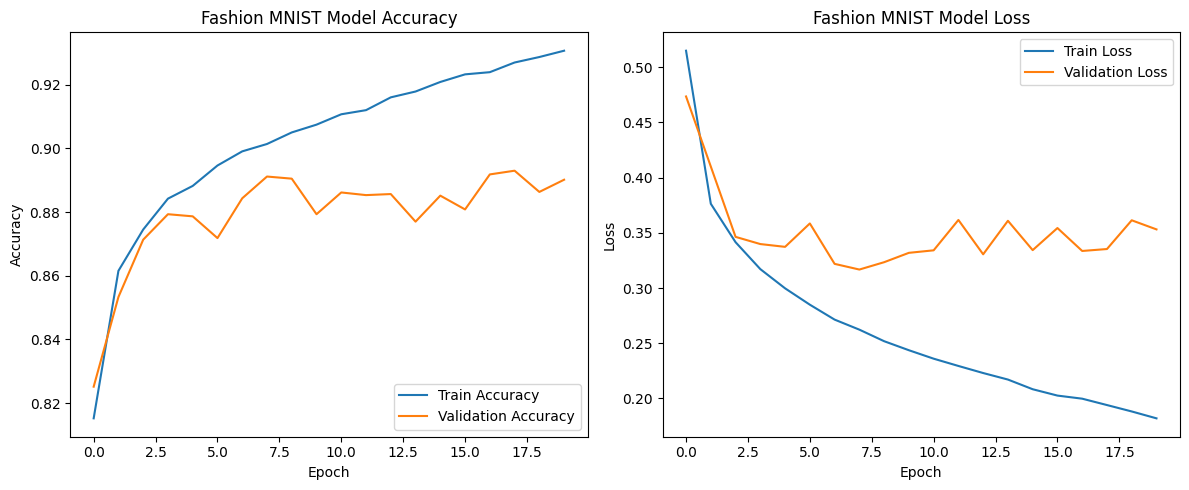

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history_fashion.history['accuracy'], label='Train Accuracy')
plt.plot(history_fashion.history['val_accuracy'], label='Validation Accuracy')
plt.title('Fashion MNIST Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history_fashion.history['loss'], label='Train Loss')
plt.plot(history_fashion.history['val_loss'], label='Validation Loss')
plt.title('Fashion MNIST Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

### 7. Analyze Model Performance: Confusion Matrix and Classification Report

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


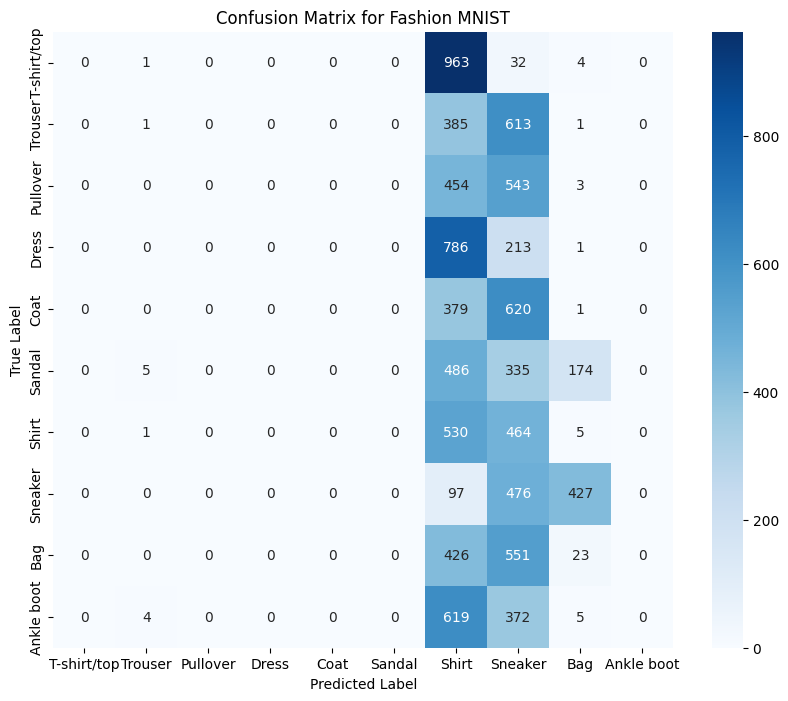

Classification Report:
               precision    recall  f1-score   support

 T-shirt/top       0.00      0.00      0.00      1000
     Trouser       0.08      0.00      0.00      1000
    Pullover       0.00      0.00      0.00      1000
       Dress       0.00      0.00      0.00      1000
        Coat       0.00      0.00      0.00      1000
      Sandal       0.00      0.00      0.00      1000
       Shirt       0.10      0.53      0.17      1000
     Sneaker       0.11      0.48      0.18      1000
         Bag       0.04      0.02      0.03      1000
  Ankle boot       0.00      0.00      0.00      1000

    accuracy                           0.10     10000
   macro avg       0.03      0.10      0.04     10000
weighted avg       0.03      0.10      0.04     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# Get predictions for the test set
y_pred_prob = model_fashion.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Define class names for Fashion MNIST for better readability
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Fashion MNIST')
plt.show()

# Generate Classification Report
report = classification_report(y_test, y_pred, target_names=class_names)
print('Classification Report:\n', report)